In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#import mnist
from torchvision.datasets import MNIST

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# class Encoder(nn.Module):
#     def __init__(self, input_dim, latent_dim):
#         super(Encoder, self).__init__()
#         self.fc = nn.Sequential(
#             nn.Conv2d(1, 16, 3, stride=2, padding=1),  # (16, 14, 14)
#             nn.ReLU(True),
#             nn.Conv2d(16, 32, 3, stride=2, padding=1),  # (32, 7, 7)
#             nn.ReLU(True),
#             nn.Conv2d(32, 64, 7)  # (64, 1, 1)
#         )
    
#     def forward(self, x):
#         return self.fc(x)

# class Decoder(nn.Module):
#     def __init__(self, latent_dim, output_dim):
#         super(Decoder, self).__init__()
#         self.fc = nn.Sequential(
#             nn.ConvTranspose2d(64, 32, 7),  # (32, 7, 7)
#             nn.ReLU(True),
#             nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # (16, 14, 14)
#             nn.ReLU(True),
#             nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # (1, 28, 28)
#             nn.Sigmoid()
#         )
    
#     def forward(self, z):
#         return self.fc(z)

class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            # nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(True),
            nn.Linear(256, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 32)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),  # For pixel values between 0 and 1
            # nn.Unflatten(1, (1, 28, 28))
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
mnist = MNIST(root='data', train=True, download=True, transform=None)
data, labels = mnist.data, mnist.targets
data = data[labels == 3][:3000]
labels = labels[labels == 3]
data = torch.tensor(data, dtype=torch.float32).to(device)
data = data / 255.0  # Normalize the images to [0, 1]
data = data.view(data.size(0), -1)  # Flatten the images
mnist_val = MNIST(root='data', train=False, download=True, transform=None)
val_data, val_labels = mnist_val.data, mnist_val.targets
val_data = val_data[val_labels == 3][:1000]
val_labels = val_labels[val_labels == 3]
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)
val_data = val_data / 255.0  # Normalize the images to [0, 1]
val_data = val_data.view(val_data.size(0), -1)  # Flatten the images

/tmp/ipykernel_213583/2209897768.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data, dtype=torch.float32).to(device)
/tmp/ipykernel_213583/2209897768.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_data = torch.tensor(val_data, dtype=torch.float32).to(device)


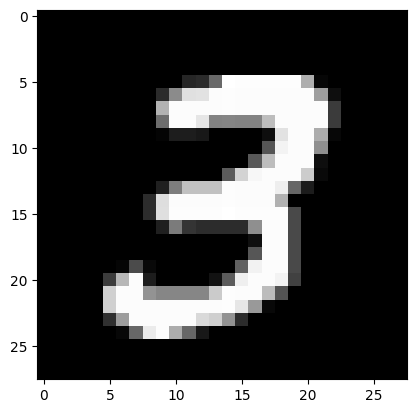

In [4]:
plt.imshow(data[0].view(28, 28).cpu().numpy(), cmap='gray')
plt.show()

In [5]:
# define model parameters
latent_dim = 32
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 256

train_dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# model_path = "models/conformal_autoencoder_half_sphere.pth"
# optimizer_path = "models/conformal_autoencoder_half_sphere_optimizer.pth"

In [6]:
from metrics import conformality_angle_loss

In [7]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
conformal_autoencoder = ConformalAutoencoder(encoder, decoder, lambda_conf=100.0).to(device)
conformal_autoencoder.conformality_loss = conformality_angle_loss
optmizer, scheduler = conformal_autoencoder.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100, scheduler_kwargs={"step_size": 100, "gamma": 0.5})

Epoch [100/1000], Loss: 0.02736681, Reconstruction Loss: 0.02683598, Conformal Loss: 0.00000531
Epoch [100/1000], Validation Loss: 0.02888712, Reconstruction Loss: 0.02834036, Conformal Loss: 0.00000547
Epoch [200/1000], Loss: 0.02370870, Reconstruction Loss: 0.02329146, Conformal Loss: 0.00000417
Epoch [200/1000], Validation Loss: 0.02781265, Reconstruction Loss: 0.02744334, Conformal Loss: 0.00000369
Epoch [300/1000], Loss: 0.02216882, Reconstruction Loss: 0.02173619, Conformal Loss: 0.00000433
Epoch [300/1000], Validation Loss: 0.02750818, Reconstruction Loss: 0.02710471, Conformal Loss: 0.00000403
Epoch [400/1000], Loss: 0.02049785, Reconstruction Loss: 0.02002656, Conformal Loss: 0.00000471
Epoch [400/1000], Validation Loss: 0.02613530, Reconstruction Loss: 0.02569771, Conformal Loss: 0.00000438
Epoch [500/1000], Loss: 0.01991461, Reconstruction Loss: 0.01951018, Conformal Loss: 0.00000404
Epoch [500/1000], Validation Loss: 0.02608479, Reconstruction Loss: 0.02564888, Conformal Lo

In [8]:
model_path = "models/conformal_autoencoder_mnist.pth"
optimizer_path = "models/conformal_autoencoder_mnist_optimizer.pth"

In [9]:

conformal_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/conformal_autoencoder_mnist.pth at epoch 1001
Optimizer and scheduler saved to models/conformal_autoencoder_mnist_optimizer.pth


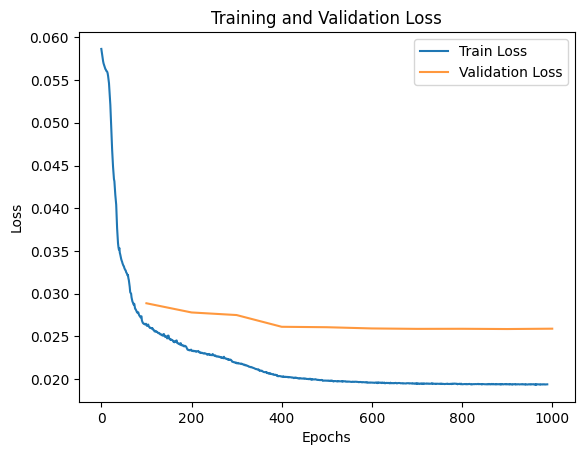

In [10]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

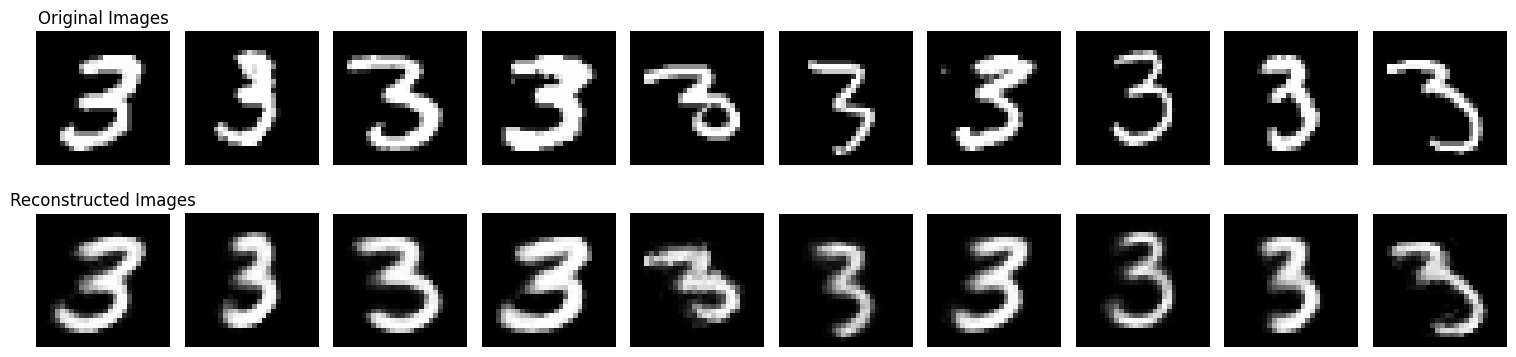

In [12]:
#Encode the data
encoded_data = conformal_autoencoder.encode(data)
# Decode the data
decoded_data = conformal_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Plot the original and reconstructed images
n_images = 10
fig, axes = plt.subplots(2, n_images, figsize=(15, 4))
for i in range(n_images):
    axes[0, i].imshow(data[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(decoded_data[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original Images')
axes[1, 0].set_title('Reconstructed Images')
plt.tight_layout()
plt.show()

In [ ]:
from torch.func import functional_call, jacrev, vmap

def gini(w: torch.Tensor) -> torch.Tensor:
    r"""The Gini coefficient from the `"Improving Molecular Graph Neural
    Network Explainability with Orthonormalization and Induced Sparsity"
    <https://arxiv.org/abs/2105.04854>`_ paper.

    Computes a regularization penalty :math:`\in [0, 1]` for each row of a
    matrix according to

    .. math::
        \mathcal{L}_\textrm{Gini}^i = \sum_j^n \sum_{j'}^n \frac{|w_{ij}
         - w_{ij'}|}{2 (n^2 - n)\bar{w_i}}

    and returns an average over all rows.

    Args:
        w (torch.Tensor): A two-dimensional tensor.
    """
    s = 0
    for row in w:
        t = row.repeat(row.size(0), 1)
        u = (t - t.T).abs().sum() / (2 * (row.size(-1)**2 - row.size(-1)) *
                                     row.abs().mean() + torch.finfo().eps)
        s += u
    s /= w.shape[0]
    return s

def get_batch_jacobian(func, inputs):
    params = dict(func.named_parameters())

    def fmodel(params, inputs):
        return functional_call(func, params, inputs)

    jacobians = vmap(jacrev(fmodel, argnums=(1)), in_dims=(None,0))(params, inputs)
    return jacobians

def evaluate_conformality(model, data):
    # still needs flattening for convolutions
    model.eval()
    with torch.no_grad():
        data_dim = data.shape[1]
        # latent samples
        latent = model.encode(data)
        latent_dim = latent.shape[1]

        # Compute the Jacobian of the decoder
        jacobians = get_batch_jacobian(model.decoder, latent)
        jTjs = torch.einsum('bji,bjk->bik', jacobians, jacobians)
        traces = vmap(torch.trace)(jTjs)
        lambda_factors = traces / latent.shape[1]

        # gini for diagonal elements
        diagonals = jTjs.diagonal(dim1=1, dim2=2)
        gini_value = gini(diagonals)

        # off diag mean, norm
        off_diagonal = jTjs - torch.diag_embed(diagonals)
        off_diag_mean = off_diagonal.abs().mean(dim=(1, 2))
        off_diag_norm = off_diagonal.norm(dim=(1, 2))
        off_diag_mean_normed = off_diag_mean / lambda_factors
        off_diag_norm_normed = off_diag_norm / lambda_factors

        # jTj - lambda*I mean, norm
        eye = torch.eye(jTjs.shape[1], device=jTjs.device).repeat(jTjs.shape[0], 1, 1)
        jTj_minus_lambdaI = jTjs - lambda_factors.unsqueeze(1).unsqueeze(2).repeat(1, jTjs.shape[1], jTjs.shape[1]) * eye
        jTj_minus_lambdaI_mean = jTj_minus_lambdaI.abs().mean(dim=(1, 2))
        jTj_minus_lambdaI_norm = jTj_minus_lambdaI.norm(dim=(1, 2))
        jTj_minus_lambdaI_mean_normed = jTj_minus_lambdaI_mean / lambda_factors
        jTj_minus_lambdaI_norm_normed = jTj_minus_lambdaI_norm / lambda_factors

        # determinant of jacobian vs sqrt lambda**m
        jacobian_determinants = torch.sqrt(torch.linalg.det(jTjs))
        determinant_vs_estimate = jacobian_determinants / (torch.sqrt(lambda_factors**latent_dim) + torch.finfo(torch.float32).eps)

        # std of latent space
        latent_std = latent.std(dim=0)
        
        return {
            'diagonal_gini': gini_value,
            'lambda_mean': lambda_factors.mean(),
            'lambda_std': lambda_factors.std(),
            'lambda_std_normed': lambda_factors.std() /lambda_factors.mean(),
            'off_diag_mean': off_diag_mean.mean(),
            'off_diag_norm': off_diag_norm.mean(),
            'off_diag_mean_normed': off_diag_mean_normed.mean(),
            'off_diag_norm_normed': off_diag_norm_normed.mean(),
            'jTj_minus_lambdaI_mean': jTj_minus_lambdaI_mean.mean(),
            'jTj_minus_lambdaI_norm': jTj_minus_lambdaI_norm.mean(),
            'jTj_minus_lambdaI_mean_normed': jTj_minus_lambdaI_mean_normed.mean(),
            'jTj_minus_lambdaI_norm_normed': jTj_minus_lambdaI_norm_normed.mean(),
            'determinant_vs_estimate_mean': determinant_vs_estimate.mean(),
            'determinant_vs_estimate_std': determinant_vs_estimate.std(),
            'latent_std': latent_std.mean(),
            'latent_std_max': latent_std.max(),
            'latent_std_min': latent_std.min(),
            'latent_norm': latent.norm(),
        }

In [14]:
stats = evaluate_conformality(conformal_autoencoder, data[:100])
print("Conformality Statistics:")
for key, value in stats.items():
    print(f"{key}: {value.item():.4f}")
print("Reconstruction Error:")
print(torch.nn.MSELoss()(data, conformal_autoencoder(data)).item())

Conformality Statistics:
diagonal_gini: 0.1134
lambda_mean: 0.0002
lambda_std: 0.0000
lambda_std_normed: 0.2446
off_diag_mean: 0.0000
off_diag_norm: 0.0008
off_diag_mean_normed: 0.1144
off_diag_norm_normed: 4.7533
jTj_minus_lambdaI_mean: 0.0000
jTj_minus_lambdaI_norm: 0.0008
jTj_minus_lambdaI_mean_normed: 0.1193
jTj_minus_lambdaI_norm_normed: 4.8865
determinant_vs_estimate_mean: 0.0000
determinant_vs_estimate_std: 0.0000
latent_std: 123.7281
latent_std_max: 166.4425
latent_std_min: 73.8249
latent_norm: 12908.1885
Reconstruction Error:
0.019015459343791008


In [14]:
num = 100
J = torch.zeros((num, 32, 32))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))
print(torch.diag(J.mean(dim=0)))
print(torch.mean(J))

tensor([[ 1.4175e-04,  1.1720e-05, -7.7730e-06,  ...,  1.3605e-05,
         -9.0934e-06,  2.2198e-05],
        [ 1.1720e-05,  1.3744e-04, -3.3970e-07,  ..., -2.9070e-06,
         -1.5261e-05, -7.3141e-08],
        [-7.7730e-06, -3.3970e-07,  1.3033e-04,  ..., -7.8360e-06,
         -1.0417e-05, -6.9831e-06],
        ...,
        [ 1.3605e-05, -2.9070e-06, -7.8360e-06,  ...,  1.2188e-04,
         -6.6970e-06,  1.8569e-05],
        [-9.0934e-06, -1.5261e-05, -1.0417e-05,  ..., -6.6970e-06,
          1.4246e-04, -4.3758e-06],
        [ 2.2198e-05, -7.3141e-08, -6.9831e-06,  ...,  1.8569e-05,
         -4.3758e-06,  1.4652e-04]])
tensor([[5.1728e-05, 2.4491e-05, 2.7695e-05,  ..., 2.3851e-05, 2.5365e-05,
         3.0836e-05],
        [2.4491e-05, 4.9999e-05, 2.7274e-05,  ..., 3.2976e-05, 2.6599e-05,
         2.2159e-05],
        [2.7695e-05, 2.7274e-05, 5.5696e-05,  ..., 3.2074e-05, 2.8608e-05,
         2.8378e-05],
        ...,
        [2.3851e-05, 3.2976e-05, 3.2074e-05,  ..., 4.5118e-05, 2

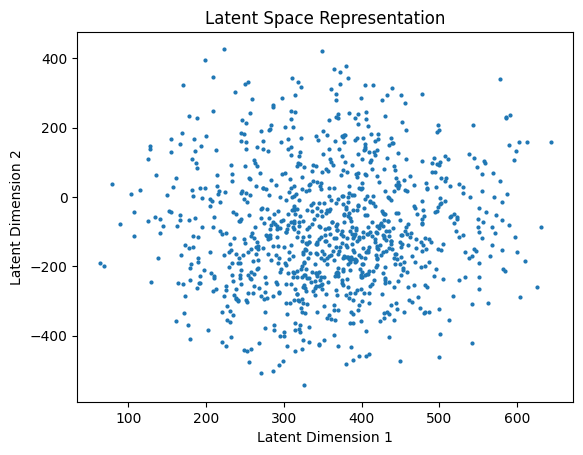

In [16]:
plt.plot(encoded_data[:1000, 0].cpu().numpy(), encoded_data[:1000, 1].cpu().numpy(), 'o', markersize=2)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Representation')
plt.show()

In [9]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = ConformalAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

FileNotFoundError: Checkpoint file not found: models/conformal_autoencoder_mnist.pth